In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from scipy.signal import find_peaks
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from astropy.timeseries import LombScargle, BoxLeastSquares


In [2]:
data = []
def is_float(x):
    try:
        float(x)
        return True
    except:
        return False

def to_float(x):
    if x == "-":
        return np.nan
    try:
        return float(x)
    except:
        return np.nan

with open("list.dat", "r") as f:
    for line in f:
        parts = line.split()
        # Ignorar líneas vacías
        if len(parts) < 5:
            continue
        obj_id = parts[0]
        ra = parts[1]
        dec = parts[2]
        # Buscar inicio de columnas numéricas
        first_num = None
        for i in range(3, len(parts)):
            if is_float(parts[i]) or parts[i] == "-":
                first_num = i
                break
        if first_num is None:
            continue
        # Clasificaciones
        class_parts = parts[3:first_num]
        tipo1 = class_parts[0] if len(class_parts) > 0 else None
        tipo2 = class_parts[1] if len(class_parts) > 1 else None
        # Extraer columnas de forma segura
        mag_I = to_float(parts[first_num]) if len(parts) > first_num else np.nan
        mag_V = to_float(parts[first_num + 1]) if len(parts) > first_num + 1 else np.nan
        periodo = to_float(parts[first_num + 2]) if len(parts) > first_num + 2 else np.nan
        amplitud = to_float(parts[first_num + 3]) if len(parts) > first_num + 3 else np.nan
        
        data.append([obj_id,ra,dec,tipo1,tipo2,mag_I,mag_V,periodo,amplitud])

df = pd.DataFrame(data, columns=["ID","RA","DEC","Tipo","Subtipo","I","V","Periodo","Amplitud"])

print(df.head())
print(df.shape)

               ID           RA          DEC   Tipo Subtipo       I       V  \
0   LMC563.16.842  05:46:55.53  -66:30:47.6  OTHER    None  18.925  18.981   
1  LMC563.16.1142  05:46:57.17  -66:24:53.9  RRLYR    RRab  19.091  19.745   
2     LMC563.16.8  05:46:57.78  -66:26:43.4    LPV   OSARG  14.662  16.383   
3  LMC563.16.9286  05:46:59.24  -66:18:01.0    ECL    None  18.690  18.808   
4  LMC563.16.2137  05:47:00.94  -66:25:36.0  OTHER    None  19.526  19.529   

      Periodo  Amplitud  
0    1.850940     0.069  
1    0.494447     0.839  
2  369.000000     0.045  
3    0.972667     0.264  
4    0.850470     0.142  
(6789, 9)


In [3]:
# 1. Agrupar por la clase principal ('Tipo') y contar
# 'value_counts' ya los ordena de mayor a menor por defecto
conteo_clases = df['Tipo'].value_counts()
print("\n" + "="*40)
print("RESUMEN DE ESTRELLAS POR CLASE PRINCIPAL")
print("="*40)
# 2. Imprimir los resultados con un formato claro
for clase, cantidad in conteo_clases.items():
    print(f"{clase:<15} : {cantidad:>8} objetos")
print("-" * 40)
print(f"{'TOTAL':<15} : {conteo_clases.sum():>8} objetos")
print("="*40)


RESUMEN DE ESTRELLAS POR CLASE PRINCIPAL
LPV             :     2799 objetos
OTHER           :     1473 objetos
ECL             :     1376 objetos
RRLYR           :      686 objetos
DSCT            :      159 objetos
ELL             :      156 objetos
DCEP            :      132 objetos
T2CEP           :        5 objetos
ACEP            :        3 objetos
----------------------------------------
TOTAL           :     6789 objetos


Pulsadores radiales(RRKYR, DSCUTI, DCEPHEID, T2CEPHEID, ANOMALOUSCEPHEID)

En su mayoría, pulsan con menos de 20 días de periodo, aunque algunas lo hacen por más, y las cefeidas clásicas se reportan a más de 100 días. 


Todas tienen varios modos de oscilación, 


Delta Scuti variables are fainter, have shorter pulsation periods, and smaller masses than classical Cepheids, but both groups obey the same period-luminosity relation and it is simply a matter of convention which period defines a boundary between them.


Además, todas son "toboganes" hacia la derecha

LPVARIABLES

OTHER

BINARYECLIPSANTES, ELLIPSOIDALES

Iguales, o similares, porque las binarias eclipsantes tienen un eclipse grande y otro más pequeño, y lo mismo pasa con las elipsoidales. Mientras que con las unas es por el brillo entre una y su compañera, para las elipsoidales es porque una de las dos estrellas hala a la otra y le da una forma de elipse: los polos son más brillantes que el ecuador, y se nota mucho del lado puntiagudo de la estrella.

In [4]:
#Este código es para separar las clases de las features. YUPIIII

¿Qué features poner?

TEnemos que conocer el periodo. Una vez conocido el periodo(lo da el documento, pero volverlo a buscar con Lomb Scargle?), cómo hacemos para saber que la distribución magnitud contra fase es sinusoidal, diente de sierra, etc? 


Tenemos los datos fotométricos, así que hacer LS no es imposible, y lo haríamos todo en I.


Ahora, para distinguir formas de funciones, podemos buscar distancia en fase entre mínimos y máximos, y máximos y mínimos. la primera es muy corta para dientes de sierra, y la segunda muy larga. Para las otras, es más estándar y su diferencia debería ser cercana a cero.


Además, comparar mínimos y máximos entre sí nos ayuda a las binarias, diría yo. Pero y la precesión de Herzprung no nos jodería ahí?


PERIODO, DELTA MIN-MAX, DELTA MAX-MIN, DELTA MIN-MIN

Va a tocar tener en consideración cómo hacemos para las binarias, porque lomb scargle a un orden no va a funcionar... serían 12, y no va a dar en esta vida. Pero la gran mayoría funciona! podemos encontrar otra manera que no sea MIN-MIN para claificarlas?

La Amplitud cómo nos ayuda?

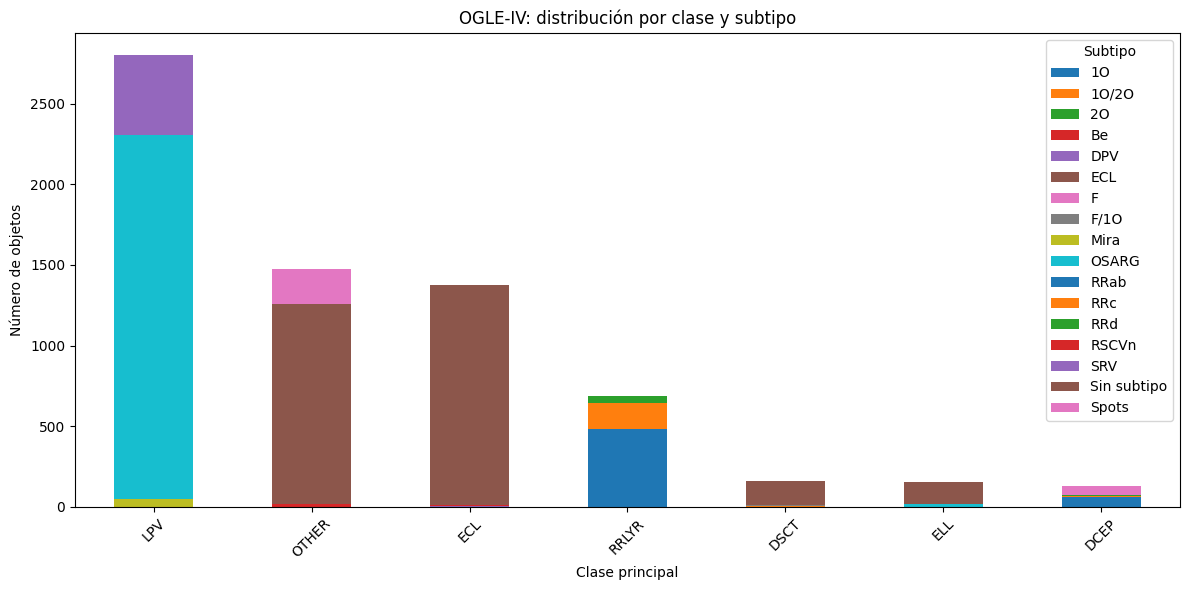

In [5]:
# Eliminar T2CEP y ACEP
df_filtered = df[~df["Tipo"].isin(["T2CEP", "ACEP"])].copy()
# Subtipos vacíos
df_filtered["Subtipo"] = df_filtered["Subtipo"].fillna("Sin subtipo")
# Conteos
counts = (df_filtered.groupby(["Tipo", "Subtipo"]).size().unstack(fill_value=0))
# Ordenar por abundancia
counts = counts.loc[counts.sum(axis=1).sort_values(ascending=False).index]
# Histograma apilado
ax = counts.plot(kind="bar",stacked=True,figsize=(12,6))

plt.xlabel("Clase principal")
plt.ylabel("Número de objetos")
plt.title("OGLE-IV: distribución por clase y subtipo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Eliminamos columnas innecesarias y nos preparamos para encontrar las features interesantes que mencionamos anteriormente:


Periodo


Deltas Min-Max, Max-Min, Min-Min

In [6]:
# Eliminar clases no deseadas
df = df[~df["Tipo"].isin(["T2CEP", "ACEP"])].copy()

# Eliminar filas sin período OGLE
df_sin_periodo = df[df["Periodo"].isna()].copy()
df = df[df["Periodo"].notna()].copy()

# Eliminar columnas innecesarias
df = df.drop(columns=["RA", "DEC", "V"])

# Reiniciar índices
df.reset_index(drop=True, inplace=True)

print(df.head())
print(df.shape)

               ID   Tipo Subtipo       I     Periodo  Amplitud
0   LMC563.16.842  OTHER    None  18.925    1.850940     0.069
1  LMC563.16.1142  RRLYR    RRab  19.091    0.494447     0.839
2     LMC563.16.8    LPV   OSARG  14.662  369.000000     0.045
3  LMC563.16.9286    ECL    None  18.690    0.972667     0.264
4  LMC563.16.2137  OTHER    None  19.526    0.850470     0.142
(6705, 6)


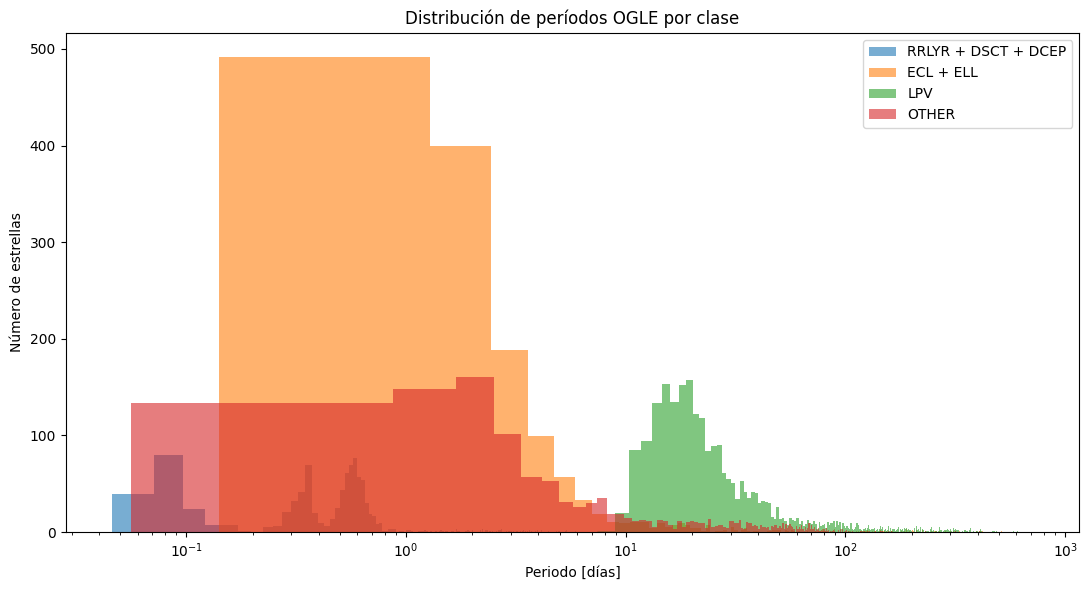

In [7]:
pulsantes = ["RRLYR","DSCT","DCEP"]
binarias = ["ECL","ELL"]
lpv = ["LPV"]
other = ["OTHER"]

df_puls = df[df["Tipo"].isin(pulsantes)]
df_bin = df[df["Tipo"].isin(binarias)]
df_lpv = df[df["Tipo"].isin(lpv)]
df_other = df[df["Tipo"].isin(other)]

plt.figure(figsize=(11,6))
plt.hist(df_puls["Periodo"].dropna(),bins=500,alpha=0.6,label="RRLYR + DSCT + DCEP")
plt.hist(df_bin["Periodo"].dropna(),bins=500,alpha=0.6,label="ECL + ELL")
plt.hist(df_lpv["Periodo"].dropna(),bins=500,alpha=0.6,label="LPV")
plt.hist(df_other["Periodo"].dropna(),bins=500,alpha=0.6,label="OTHER")

plt.xscale("log")
plt.xlabel("Periodo [días]")
plt.ylabel("Número de estrellas")
plt.title("Distribución de períodos OGLE por clase")
plt.legend()
plt.tight_layout()
plt.show()

Empezar a correr desde acá cuando ya se ha hecho más de una vez, o correr desde el principio.

In [8]:
# Separación reproducible
df_train, df_classify = train_test_split(df,train_size=1000,random_state=42,shuffle=True)

# Reiniciar índices
df_train = df_train.reset_index(drop=True)
df_classify = df_classify.reset_index(drop=True)

print("Entrenamiento:", df_train.shape)
print("Clasificación:", df_classify.shape)

Entrenamiento: (1000, 6)
Clasificación: (5705, 6)


In [9]:
PHOT_PATH = "phot/I"

def load_lightcurve(star_id):
    filepath = os.path.join(PHOT_PATH, f"{star_id}.dat")
    if not os.path.exists(filepath):
        return None, None, None
    try:
        data = np.loadtxt(filepath)
        t = data[:,0]
        mag = data[:,1]
        err = data[:,2]
        return t, mag, err
    except:
        return None, None, None

In [10]:
def lomb_scargle_period(t,mag,star_type=None,subtype=None,samples_per_peak=10):
    # -----------------------------
    # Limpiar datos
    # -----------------------------
    mask = np.isfinite(t) & np.isfinite(mag)
    t = t[mask]
    mag = mag[mask]
    if len(t) < 30:
        return np.nan, None, None
    # -----------------------------
    # Centrar magnitudes
    # -----------------------------
    mag = mag - np.median(mag)
    # -----------------------------
    # Rangos físicos
    # -----------------------------
    min_period = 0.05
    max_period = 1000
    if star_type == "RRLYR":
        min_period = 0.15
        max_period = 1.2
    elif star_type == "LPV":
        # Subtipos LPV
        if subtype == "OSARG":
            min_period = 5
            max_period = 100
        elif subtype == "SRV":
            min_period = 10
            max_period = 300
        elif subtype == "Mira":
            min_period = 50
            max_period = 1500
        else:
            min_period = 5
            max_period = 500
    elif star_type == "ECL":
        min_period = 0.1
        max_period = 100
    elif star_type == "DCEP":
        min_period = 0.5
        max_period = 150
    # -----------------------------
    # Frecuencias
    # -----------------------------
    max_frequency = 1/min_period
    min_frequency = max(1/max_period,1/(t.max() - t.min()))
    # -----------------------------
    # Lomb Scargle
    # -----------------------------
    ls = LombScargle(t,mag,center_data=True)
    frequency, power = ls.autopower(minimum_frequency=min_frequency,maximum_frequency=max_frequency,samples_per_peak=samples_per_peak)
    # -----------------------------
    # Ordenar TODOS los picos
    # -----------------------------
    sorted_idx = np.argsort(power)[::-1]
    aliases = [1.0, 0.5, 2.0]
    best_period = None
    for idx in sorted_idx[:50]:
        period = 1 / frequency[idx]
        # -------------------------
        # Evitar aliases
        # -------------------------
        bad_alias = False
        for alias in aliases:
            if abs(period - alias) < 0.05:
                bad_alias = True
                break
        if bad_alias:
            continue
        # -------------------------
        # Restricciones LPV
        # -------------------------
        if star_type == "LPV":
            if period < 5:
                continue
        best_period = period
        break
    # -----------------------------
    # Fallback
    # -----------------------------
    if best_period is None:
        best_period = 1 / frequency[np.argmax(power)]
    # -----------------------------
    # Eclipsantes
    # -----------------------------
    if star_type == "ECL":
        best_period *= 2
    # Detectar soluciones pegadas al borde
    if best_period > 0.95 * max_period:
        best_period = np.nan
    return best_period, frequency, power

Pruebas sobre una estrella

In [11]:
example_index = 100
example_star = df_train.iloc[example_index]
example_id = example_star["ID"]
print("Estrella ejemplo:", example_id)
print("Tipo:", example_star["Tipo"])
print("Subtipo:", example_star["Subtipo"])

Estrella ejemplo: LMC562.05.9009
Tipo: DCEP
Subtipo: F


In [12]:
star = example_star
t, mag, err = load_lightcurve(star["ID"])
print(star["ID"])
print(len(t))

LMC562.05.9009
345


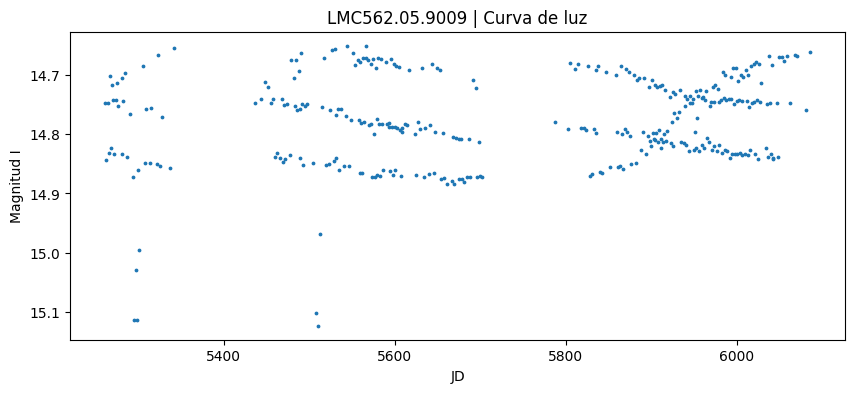

In [13]:
plt.figure(figsize=(10,4))
plt.scatter(t, mag, s=3)
plt.gca().invert_yaxis()
plt.xlabel("JD")
plt.ylabel("Magnitud I")
plt.title(f"{star['ID']} | Curva de luz")
plt.show()

In [14]:
period_ls, freq, power = lomb_scargle_period(t,mag,star_type=star["Tipo"],subtype=star["Subtipo"])
print("OGLE:", star["Periodo"])
print("Lomb-Scargle:", period_ls)

OGLE: 2.987879
Lomb-Scargle: 2.9880506250044188


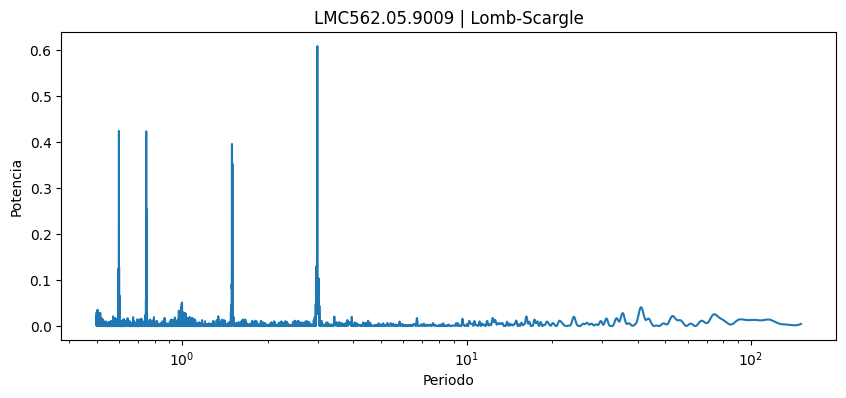

In [15]:
plt.figure(figsize=(10,4))
plt.plot(1/freq, power)
plt.xlabel("Periodo")
plt.ylabel("Potencia")
plt.xscale("log")
plt.title(f"{star['ID']} | Lomb-Scargle")
plt.show()

In [16]:
def phase_fold(t, period):
    phase = (t % period) / period
    return phase

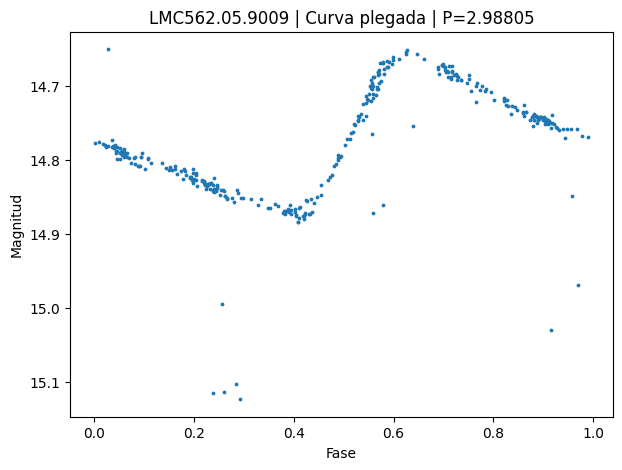

In [17]:
phase = phase_fold(t, period_ls)
plt.figure(figsize=(7,5))
plt.scatter(phase, mag, s=3)
plt.gca().invert_yaxis()
plt.xlabel("Fase")
plt.ylabel("Magnitud")
plt.title(f"{star['ID']} | Curva plegada | P={period_ls:.5f}")
plt.show()

Aquí se acaban las puebas sobre la estrella

In [18]:
results = []

for _, star in df_train.iterrows():
    t, mag, err = load_lightcurve(star["ID"])
    if t is None:
        continue
    try:
        period_ls, freq, power = lomb_scargle_period(t,mag,star_type=star["Tipo"],subtype=star["Subtipo"])
        results.append({"ID": star["ID"],"Tipo": star["Tipo"],"Subtipo": star["Subtipo"],
            "Periodo_OGLE": star["Periodo"],"Periodo_LS": period_ls})
    except:
        continue
features_df = pd.DataFrame(results)
print(features_df)

                 ID   Tipo Subtipo  Periodo_OGLE  Periodo_LS
0    LMC563.08.8034    ECL    None      0.748787    0.748773
1    LMC571.01.4321    LPV   OSARG     21.841000   21.828878
2    LMC562.21.9858  OTHER    None      1.645070    1.644931
3    LMC563.21.3909    ECL    None      0.596507    0.596521
4    LMC562.19.8132    ECL    None      0.580783    0.580774
..              ...    ...     ...           ...         ...
995   LMC562.02.683    ECL    None      3.459870    3.460264
996  LMC570.22.5125    LPV   OSARG     49.890000   50.114744
997  LMC570.30.3312    ECL    None      0.959039    1.846945
998  LMC571.12.4453  RRLYR    RRab      0.632495    0.632444
999  LMC562.32.5326   DSCT    None      0.078112    0.078112

[1000 rows x 5 columns]


In [19]:
features_df["Frac_Error"] = (np.abs(features_df["Periodo_LS"] - features_df["Periodo_OGLE"])
    / features_df["Periodo_OGLE"])
print(features_df["Frac_Error"].describe())


count    9.720000e+02
mean     3.734440e+00
std      4.292455e+01
min      1.131192e-08
25%      3.995375e-05
50%      4.604307e-04
75%      4.015649e-03
max      7.836296e+02
Name: Frac_Error, dtype: float64


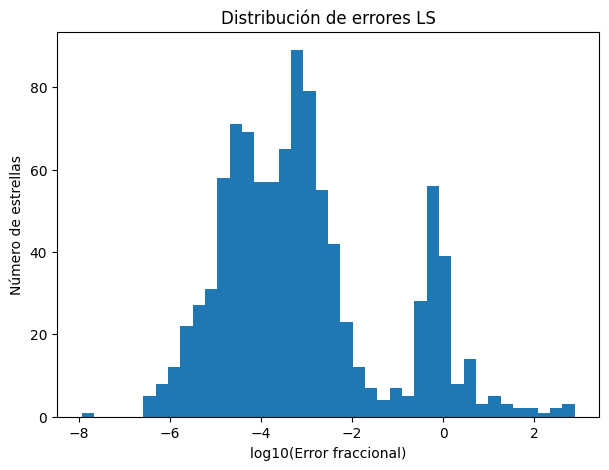

In [20]:
plt.figure(figsize=(7,5))
plt.hist(np.log10(features_df["Frac_Error"].dropna()),bins=40)
plt.xlabel("log10(Error fraccional)")
plt.ylabel("Número de estrellas")
plt.title("Distribución de errores LS")
plt.show()

In [21]:
bad = features_df[features_df["Frac_Error"] > 0.5]
print(len(bad))
print(bad["Tipo"].value_counts())
print(bad[["ID","Tipo","Subtipo","Periodo_OGLE","Periodo_LS","Frac_Error"]])

117
Tipo
LPV      57
ECL      25
OTHER    19
ELL      11
RRLYR     4
DCEP      1
Name: count, dtype: int64
                 ID   Tipo Subtipo  Periodo_OGLE  Periodo_LS  Frac_Error
6      LMC571.20.28    LPV   OSARG     15.493000   34.849895    1.249396
13    LMC562.14.106    ECL    None      2.044910    3.893678    0.904083
17   LMC570.11.5758  RRLYR    RRab      0.482286    0.933901    0.936404
22      LMC563.26.9  OTHER    None      1.360650  823.776950  604.428986
36   LMC570.28.1333    ECL    None      0.910379    1.820818    1.000066
..              ...    ...     ...           ...         ...         ...
969  LMC571.30.1171    ECL    None      2.090075    0.675794    0.676665
974   LMC562.23.165  OTHER    None     19.950000    0.949823    0.952390
979  LMC571.11.4495    LPV   OSARG     14.161000   62.229148    3.394404
981    LMC563.31.55    ELL    None    114.540000   57.206733    0.500552
997  LMC570.30.3312    ECL    None      0.959039    1.846945    0.925829

[117 rows x 6 co

In [22]:
good = features_df[features_df["Frac_Error"] < 0.05]
print(len(good) / len(features_df))

0.792


Estamos teniendo problemas con las eclipsantes(as expected), y con las LPVs, ir a mirar tantos periodos posibles nos está matando un poco...

In [23]:
def folded_lightcurve(t, mag, period):
    # --------------------------------------------------------
    # Fase
    # --------------------------------------------------------

    phase = phase_fold(t, period)

    # --------------------------------------------------------
    # Ordenar
    # --------------------------------------------------------

    idx = np.argsort(phase)

    phase = phase[idx]
    mag = mag[idx]

    # --------------------------------------------------------
    # Duplicar para continuidad
    # --------------------------------------------------------

    phase2 = np.concatenate([
        phase,
        phase + 1
    ])

    mag2 = np.concatenate([
        mag,
        mag
    ])

    return phase2, mag2

In [24]:
def smooth_folded_curve(mag, window=31, polyorder=3):

    # window debe ser impar
    if window >= len(mag):

        window = len(mag) - 1

    if window % 2 == 0:

        window += 1

    smooth_mag = savgol_filter(
        mag,
        window_length=window,
        polyorder=polyorder
    )

    return smooth_mag

In [25]:
def alternating_extrema_clean(
    phase,
    smooth_mag,
    minima_idx,
    maxima_idx
):

    # ========================================================
    # Construir lista unificada
    # ========================================================

    extrema = []

    # --------------------------------------------------------
    # Mínimos
    # --------------------------------------------------------

    for idx in minima_idx:

        extrema.append({
            "idx": idx,
            "phase": phase[idx],
            "mag": smooth_mag[idx],
            "type": "min"
        })

    # --------------------------------------------------------
    # Máximos
    # --------------------------------------------------------

    for idx in maxima_idx:

        extrema.append({
            "idx": idx,
            "phase": phase[idx],
            "mag": smooth_mag[idx],
            "type": "max"
        })

    # ========================================================
    # Ordenar por fase
    # ========================================================

    extrema = sorted(
        extrema,
        key=lambda x: x["phase"]
    )

    # ========================================================
    # Limpiar consecutivos
    # ========================================================

    cleaned = []

    for ext in extrema:

        # ----------------------------------------------------
        # Primer elemento
        # ----------------------------------------------------

        if len(cleaned) == 0:

            cleaned.append(ext)

            continue

        last = cleaned[-1]

        # ----------------------------------------------------
        # Tipos distintos
        # ----------------------------------------------------

        if ext["type"] != last["type"]:

            cleaned.append(ext)

            continue

        # ====================================================
        # Dos mínimos seguidos
        # ====================================================

        if ext["type"] == "min":

            # conservar el MÁS profundo
            # magnitud MÁS pequeña

            if ext["mag"] < last["mag"]:

                cleaned[-1] = ext

        # ====================================================
        # Dos máximos seguidos
        # ====================================================

        else:

            # conservar el MÁS alto
            # magnitud MÁS grande

            if ext["mag"] > last["mag"]:

                cleaned[-1] = ext

    # ========================================================
    # Separar nuevamente
    # ========================================================

    minima_keep = np.array([
        e["idx"]
        for e in cleaned
        if e["type"] == "min"
    ])

    maxima_keep = np.array([
        e["idx"]
        for e in cleaned
        if e["type"] == "max"
    ])

    return minima_keep, maxima_keep

In [26]:
def extract_shape_features(
    phase,
    mag,
    n_extrema=4
):

    # ========================================================
    # Suavizado
    # ========================================================

    smooth_mag = smooth_folded_curve(mag)

    # ========================================================
    # Detectar extremos
    # ========================================================

    minima_idx, _ = find_peaks(
        -smooth_mag,
        distance=20
    )

    maxima_idx, _ = find_peaks(
        smooth_mag,
        distance=20
    )

    # ========================================================
    # Validación
    # ========================================================

    if len(minima_idx) < 1 or len(maxima_idx) < 1:
        return None


    minima_idx, maxima_idx = alternating_extrema_clean(
        phase,
        smooth_mag,
        minima_idx,
        maxima_idx
    )

    # ========================================================
    # Conservar extremos principales
    # ========================================================

    minima_sorted = minima_idx[
        np.argsort(smooth_mag[minima_idx])]

    minima_keep = minima_sorted[:n_extrema]

    maxima_sorted = maxima_idx[
        np.argsort(smooth_mag[maxima_idx])[::-1]]

    maxima_keep = maxima_sorted[:n_extrema]

    # ========================================================
    # Ordenar por fase
    # ========================================================

    minima_keep = minima_keep[
        np.argsort(phase[minima_keep])
    ]

    maxima_keep = maxima_keep[
        np.argsort(phase[maxima_keep])
    ]

    # ========================================================
    # Fases y magnitudes
    # ========================================================

    minima_phase = phase[minima_keep]
    maxima_phase = phase[maxima_keep]

    minima_mag = smooth_mag[minima_keep]
    maxima_mag = smooth_mag[maxima_keep]

    # ========================================================
    # Distancias mínimo -> siguiente máximo
    # ========================================================

    delta_min_to_max = []

    for pmin in minima_phase:

        future_max = maxima_phase[maxima_phase > pmin]

        if len(future_max) == 0:
            future_max = maxima_phase + 1

        nearest_max = future_max[0]

        delta = (nearest_max - pmin) % 1

        delta_min_to_max.append(delta)

    # ========================================================
    # Distancias máximo -> siguiente mínimo
    # ========================================================

    delta_max_to_min = []

    for pmax in maxima_phase:

        future_min = minima_phase[minima_phase > pmax]

        if len(future_min) == 0:
            future_min = minima_phase + 1

        nearest_min = future_min[0]

        delta = (nearest_min - pmax) % 1

        delta_max_to_min.append(delta)

    # ========================================================
    # Diferencias entre mínimos
    # ========================================================

    minima_diff = []

    for i in range(len(minima_mag)-1):

        minima_diff.append(
            abs(minima_mag[i+1] - minima_mag[i])
        )

    # ========================================================
    # Diferencias entre máximos
    # ========================================================

    maxima_diff = []

    for i in range(len(maxima_mag)-1):

        maxima_diff.append(
            abs(maxima_mag[i+1] - maxima_mag[i])
        )

    # ========================================================
    # Features globales
    # ========================================================

    amplitude = (
        np.max(maxima_mag)
        -
        np.min(minima_mag)
    )

    return {

        "Amplitude": amplitude,

        "Mean_MinMax_Delta":
            np.mean(delta_min_to_max),

        "Mean_MaxMin_Delta":
            np.mean(delta_max_to_min),

        "Mean_Minima_Diff":
            np.mean(minima_diff)
            if len(minima_diff) > 0 else np.nan,

        "Mean_Maxima_Diff":
            np.mean(maxima_diff)
            if len(maxima_diff) > 0 else np.nan,

        "N_Minima": len(minima_keep),

        "N_Maxima": len(maxima_keep),

        # ====================================================
        # Para graficar luego
        # ====================================================

        "minima_idx": minima_keep,
        "maxima_idx": maxima_keep,
        "smooth_mag": smooth_mag
    }

Probando sobre 1 star

In [27]:
star = example_star

t, mag, err = load_lightcurve(star["ID"])

period_ls, freq, power = lomb_scargle_period(
    t,
    mag,
    star_type=star["Tipo"],
    subtype=star["Subtipo"]
)

phase2, mag2 = folded_lightcurve(
    t,
    mag,
    period_ls
)

features = extract_shape_features(
    phase2,
    mag2
)

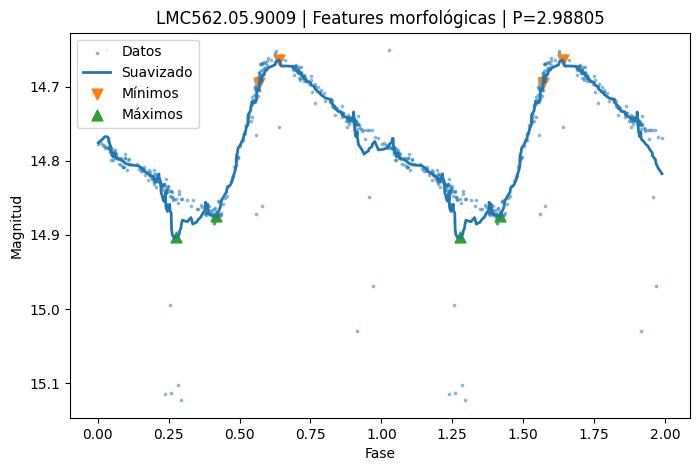

In [28]:
smooth_mag = features["smooth_mag"]
minima_idx = features["minima_idx"]
maxima_idx = features["maxima_idx"]

# ------------------------------------------------------------
# Gráfica
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.scatter(
    phase2,
    mag2,
    s=3,
    alpha=0.4,
    label="Datos"
)

plt.plot(
    phase2,
    smooth_mag,
    linewidth=2,
    label="Suavizado"
)

# Mínimos
plt.scatter(
    phase2[minima_idx],
    smooth_mag[minima_idx],
    s=60,
    marker="v",
    label="Mínimos"
)

# Máximos
plt.scatter(
    phase2[maxima_idx],
    smooth_mag[maxima_idx],
    s=60,
    marker="^",
    label="Máximos"
)

plt.gca().invert_yaxis()

plt.xlabel("Fase")
plt.ylabel("Magnitud")

plt.title(
    f"{star['ID']} | Features morfológicas | P={period_ls:.5f}"
)

plt.legend()

plt.show()

In [29]:
feature_rows = []

for _, star in df_train.iterrows():
    
    t, mag, err = load_lightcurve(star["ID"])

    if t is None:
        continue

    try:

        period_ls, freq, power = lomb_scargle_period(t,mag,star_type=star["Tipo"],subtype=star["Subtipo"])

        if np.isnan(period_ls):
            continue

        phase2, mag2 = folded_lightcurve(t,mag,period_ls)

        shape_features = extract_shape_features(
            phase2,
            mag2
        )

        if shape_features is None:
            continue

        row = {

            "ID": star["ID"],

            "Tipo": star["Tipo"],

            "Periodo_LS": period_ls
        }

        row.update(shape_features)

        feature_rows.append(row)

    except:
        continue

features_df = pd.DataFrame(feature_rows)

print(features_df.head())
print(features_df.shape)

               ID   Tipo  Periodo_LS  Amplitude  Mean_MinMax_Delta  \
0  LMC563.08.8034    ECL    0.748773   0.240781           0.288794   
1  LMC571.01.4321    LPV   21.828878   0.022641           0.512677   
2  LMC562.21.9858  OTHER    1.644931   0.081731           0.291903   
3  LMC563.21.3909    ECL    0.596521   1.082355           0.268981   
4  LMC562.19.8132    ECL    0.580774   0.033092           0.467829   

   Mean_MaxMin_Delta  Mean_Minima_Diff  Mean_Maxima_Diff  N_Minima  N_Maxima  \
0           0.211206          0.003079          0.013676         4         4   
1           0.370825          0.002312          0.001431         4         4   
2           0.611727          0.004989          0.008176         4         4   
3           0.436228          0.081452          0.660281         4         4   
4           0.273578          0.001045          0.002683         4         4   

             minima_idx            maxima_idx  \
0    [6, 217, 403, 543]  [142, 305, 468, 631]   


In [30]:
pulsantes = ["RRLYR","DSCT","DCEP"]
binarias = ["ECL","ELL"]
lpv = ["LPV"]
other = ["OTHER"]

# ============================================================
# SUBCONJUNTOS
# ============================================================

feat_puls = features_df[features_df["Tipo"].isin(pulsantes)]
feat_bin = features_df[features_df["Tipo"].isin(binarias)]
feat_lpv = features_df[features_df["Tipo"].isin(lpv)]
feat_other = features_df[features_df["Tipo"].isin(other)]

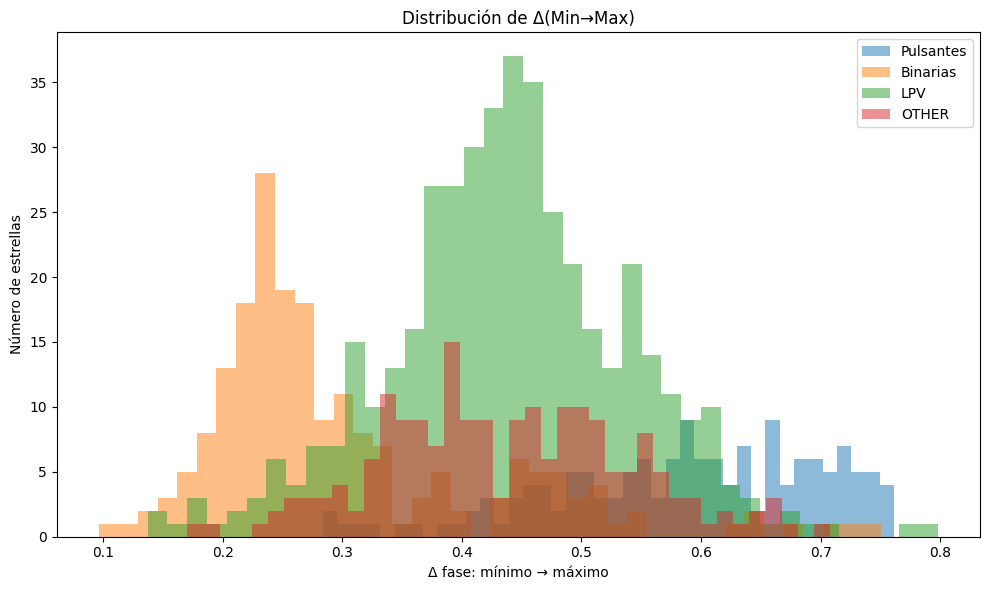

In [31]:
plt.figure(figsize=(10,6))

plt.hist(
    feat_puls["Mean_MinMax_Delta"].dropna(),
    bins=40,
    alpha=0.5,
    label="Pulsantes")

plt.hist(
    feat_bin["Mean_MinMax_Delta"].dropna(),
    bins=40,
    alpha=0.5,
    label="Binarias")

plt.hist(
    feat_lpv["Mean_MinMax_Delta"].dropna(),
    bins=40,
    alpha=0.5,
    label="LPV")

plt.hist(
    feat_other["Mean_MinMax_Delta"].dropna(),
    bins=40,
    alpha=0.5,
    label="OTHER")

plt.xlabel("Δ fase: mínimo → máximo")
plt.ylabel("Número de estrellas")
plt.title("Distribución de Δ(Min→Max)")
plt.legend()
plt.tight_layout()
plt.show()

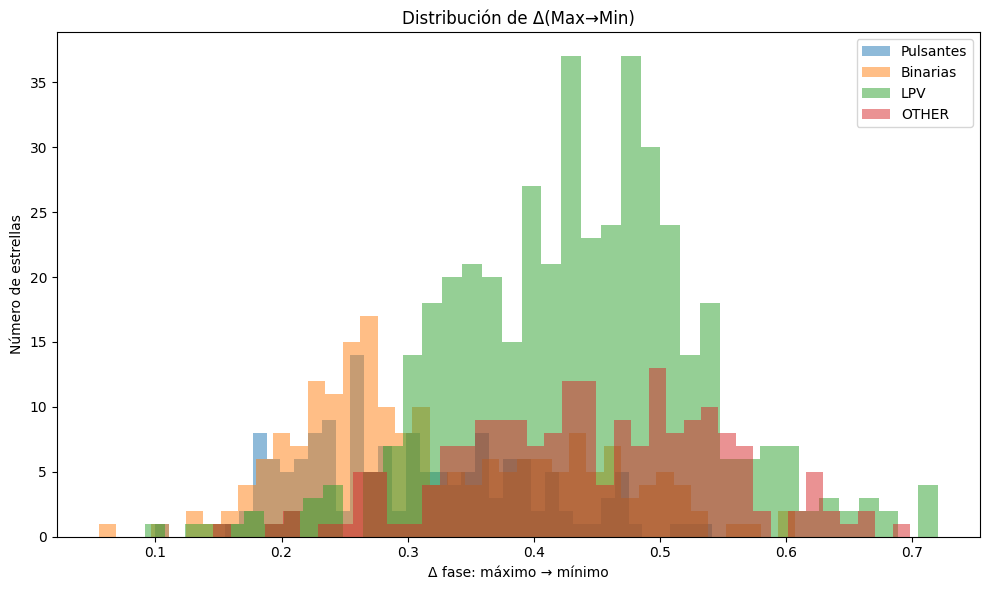

In [32]:
plt.figure(figsize=(10,6))

plt.hist(
    feat_puls["Mean_MaxMin_Delta"].dropna(),
    bins=40,
    alpha=0.5,
    label="Pulsantes"
)

plt.hist(
    feat_bin["Mean_MaxMin_Delta"].dropna(),
    bins=40,
    alpha=0.5,
    label="Binarias"
)

plt.hist(
    feat_lpv["Mean_MaxMin_Delta"].dropna(),
    bins=40,
    alpha=0.5,
    label="LPV"
)

plt.hist(
    feat_other["Mean_MaxMin_Delta"].dropna(),
    bins=40,
    alpha=0.5,
    label="OTHER"
)

plt.xlabel("Δ fase: máximo → mínimo")

plt.ylabel("Número de estrellas")

plt.title(
    "Distribución de Δ(Max→Min)"
)

plt.legend()

plt.tight_layout()

plt.show()

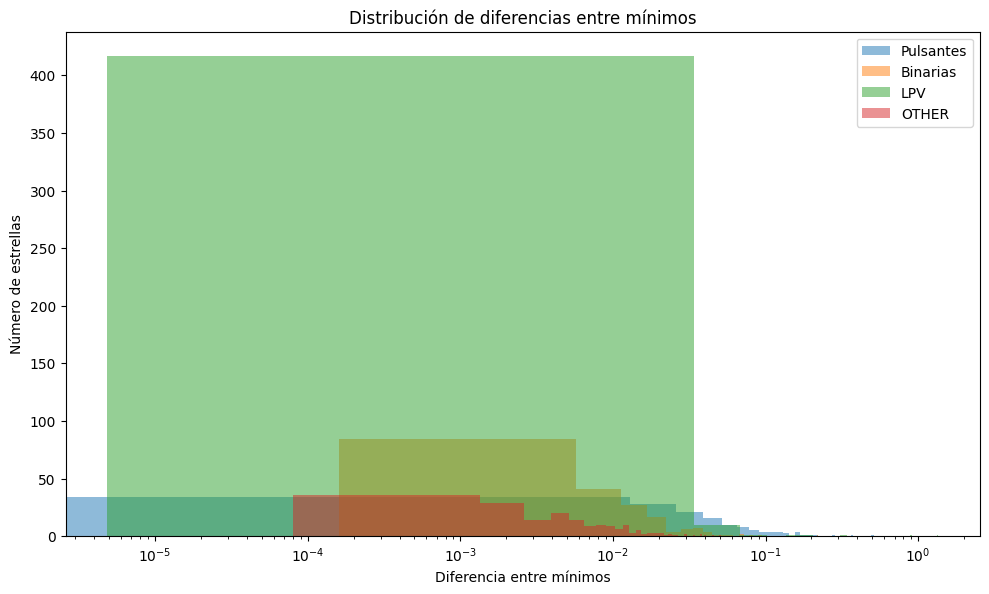

In [33]:
plt.figure(figsize=(10,6))

plt.hist(
    feat_puls["Mean_Minima_Diff"].dropna(),
    bins=40,
    alpha=0.5,
    label="Pulsantes"
)

plt.hist(
    feat_bin["Mean_Minima_Diff"].dropna(),
    bins=40,
    alpha=0.5,
    label="Binarias"
)

plt.hist(
    feat_lpv["Mean_Minima_Diff"].dropna(),
    bins=40,
    alpha=0.5,
    label="LPV"
)

plt.hist(
    feat_other["Mean_Minima_Diff"].dropna(),
    bins=40,
    alpha=0.5,
    label="OTHER"
)

plt.xlabel("Diferencia entre mínimos")

plt.ylabel("Número de estrellas")

plt.title(
    "Distribución de diferencias entre mínimos"
)

plt.legend()

plt.tight_layout()
plt.xscale("log")
plt.show()

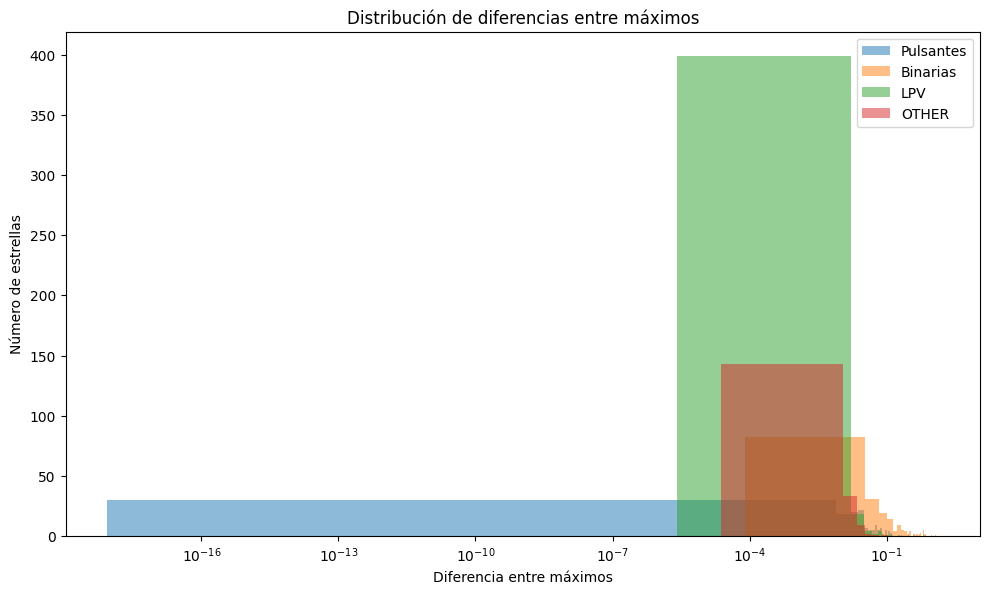

In [34]:
plt.figure(figsize=(10,6))

plt.hist(
    feat_puls["Mean_Maxima_Diff"].dropna(),
    bins=40,
    alpha=0.5,
    label="Pulsantes"
)

plt.hist(
    feat_bin["Mean_Maxima_Diff"].dropna(),
    bins=40,
    alpha=0.5,
    label="Binarias"
)

plt.hist(
    feat_lpv["Mean_Maxima_Diff"].dropna(),
    bins=40,
    alpha=0.5,
    label="LPV"
)

plt.hist(
    feat_other["Mean_Maxima_Diff"].dropna(),
    bins=40,
    alpha=0.5,
    label="OTHER"
)

plt.xlabel("Diferencia entre máximos")

plt.ylabel("Número de estrellas")

plt.title(
    "Distribución de diferencias entre máximos"
)

plt.legend()

plt.tight_layout()
plt.xscale("log")
plt.show()